In [1]:
try:
    import pytorch
except ImportError:
    #!pip3 install torch torchvision
    pass

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
# import one hot encoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_covtype
import seaborn as sns

In [2]:
BATCH_SIZE = 128
TEST_SPLIT = 0.1
VAL_SPLIT = 0.15
EPOCHS = 5
USE_WEIGHTS = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA device found.", torch.cuda.is_available())
    BATCH_SIZE = 1024
    EPOCHS = 100
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print ("MPS device found.", torch.backends.mps.is_available())
    BATCH_SIZE = 256
else:
    device = torch.device("cpu")
    print ("MPS/GPU device not found.")

CUDA device found. True


In [3]:
df = fetch_covtype(as_frame=True).frame
feature_cols = df.columns.tolist()
target_col = 'Cover_Type'
feature_cols.remove(target_col)
print(df.shape)
df.head()

(581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


## Loading Data

Managing and loading data in our PyTorch models is a bit more complex than it typically is with dataframes and scikit-learn. There's a few reasons for this, mainly that neural networks are at their best when dealing with very large datasets, so the normal process of loading the data into RAM all at once, like with an array or dataframe, is not something that'll work for most real world deep learning problems. Instead, we need to be able to load data in chunks, and often need to do some preprocessing on-the-fly as the data is being loaded. PyTorch provides two main tools to help with this: the Dataset and the DataLoader.

<b>Note:</b> there is a lot of flexibility in how these items can work, as there is with most PyTorch components. As long as the specific requirements of the class/method are met, how our code gets there can be almost anything - there's a lot more variance than with the sklearn models that we've used so far. In practice, you'll see lots of different ways to do things if you look at my examples, the text, the documentation, or things you may find online. These differences can be due to personal preference, specific needs of the data/problem, or other factors. The important part is understanding the requirements and how to meet them, rather than following a specific pattern. This is also a good chance to think agile and work iteratively; we can start with something that works, then adjust as we see both the performance of the model, and any limitations of the hardware. With some experience, you'll get a bit better at selecting a good starting point. 

### Custom Dataset

To create a custom dataset in PyTorch, we need to define a class that inherits from `torch.utils.data.Dataset`. Among other things, this class needs to convert the data into PyTorch tensors from whatever format the data is currently in (e.g., pandas DataFrame, NumPy array, etc.). For most common datatypes, the data can be fed to the tensor constructor directly. This class must implement the following methods:

<ul>
<li>`__init__`: This method initializes the dataset, loading the data and performing any necessary preprocessing.</li>
<li>`__len__`: This method returns the total number of samples in the dataset.</li>
<li>`__getitem__`: This method retrieves a sample from the dataset at the specified index.</li>
    <ul>
    <li>This item is typically returned as a tuple containing the features and the target label.</li>
    </ul>
</ul>

The dataset is responsible for managing access to the data and returning items in the correct format. For this example, we feed it a dataframe and it'll handle converting to a tensor and producing one item at a time, when asked. In other scenarios, the "access" part might be different, in particular, if we have large datasets such as images or text files that we can't fit into RAM, we might want to load the data from disk on-the-fly in the `__getitem__` method rather than loading everything into memory at once. In those cases, when to load and process the data would be mainly dependent on the specifics of the data, and the resources of the machine(s) - the priority is usually to ensure the GPU is kept running as much as possible without waiting for data to be loaded or processed.

For our data, we'll make a simple dataset that takes in a dataframe and some info about which columns to use, and produces the features and labels one at a time in the `__getitem__` method. We don't need to do too much processing, our data is already a bunch of floats, but we should scale them for the model to train effectively. We can build that into the `__init__` method so that it's done once when the dataset is created.

### Dataloader

The dataloader is the Dataset's best buddy, it takes the dataset, and manages training specific tasks such as batching, shuffling, and parallel loading. The dataloader wraps around the dataset and provides an iterable over the dataset, allowing us to easily access batches of data during training. Our primary concerns with the dataloader are:
<ul>
<li>`dataset`: The dataset from which to load the data.</li>
    <ul>
    <li>The dataset manages all the details of accessing data, the dataloader just calls the dataset's methods to get the data.</li>
    </ul>
<li>`batch_size`: How many samples per batch to load.</li>
    <ul>
    <li>Batch size is impacted by both the performance of the model and the limits of the hardware. </li>
    <li>Larger batch sizes can lead to faster training times because they allow for more parallelism and better utilization of the GPU. However, they also require more GPU memory, which is the hard limit we often run into first.</li>
    <li>Smaller batch sizes use less memory and can often lead to better generalization, but there's some 'waste' as each batch doesn't do as much processing as it could. </li>
    <li>For our smaller models, batch size of 32 or 64 is often a good starting point, but it really is a tunable parameter that we can experiment with. With some of the larger examples later, we will need to balance GPU memory with model performace to optimize the processing.</li>
    </ul>
<li>`shuffle`: Whether to shuffle the data at every epoch.</li>
    <ul>
    <li>For training data, we (almost?) always want to shuffle the data. This usually helps with generalization and convergence. If you feed the model all the True samples first, that can push the gradient descent in one direction for a long time, making it harder to converge when other samples are seen later. Shuffling ensures that the model sees a representitive mix of samples in each batch.</li>
    <li>For testing data, there's no need to shuffle, we're just running predictions (inference) on the data, so the order doesn't matter.</li>
    </ul>
</ul>

#### Batch Sampler

Since our data isn't in a simple format like a dataframe, where we can preview it easily, we often write a little helper function to grab a batch from the dataloader and give us a preview. Like most things, the details are up to us. This one is not that interesting, but when dealing with images or other data, it may be a bit more useful.

In [4]:
class CustomDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, feature_colnames: list, target_colname: str):
        self.x_tmp = dataframe[feature_colnames].values
        self.scaler = StandardScaler()
        self.x_tmp = self.scaler.fit_transform(self.x_tmp)
        self.X = torch.tensor(self.x_tmp, dtype=torch.float32)
        self.y = torch.tensor(dataframe[target_colname].values, dtype=torch.long) - 1  # Subtract 1 to make classes start from 0

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, index: int):
        return self.X[index], self.y[index]

def preview_batch(dataloader, num_prints=5):
    sample_batch = next(iter(dataloader))
    inputs, targets = sample_batch
    i = 0
    for input_tensor, target in zip(inputs, targets):
        print(f"Sample {i}:")
        print(f"Input Tensor: {input_tensor}")
        print(f"Target: {target}\n")
        i += 1
        if i >= num_prints:
            break

train, test = train_test_split(df, test_size=TEST_SPLIT, random_state=42)
train, val = train_test_split(train, test_size=VAL_SPLIT, random_state=42)

train_dataset = CustomDataset(dataframe=train, feature_colnames=feature_cols, target_colname=target_col)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = CustomDataset(dataframe=test, feature_colnames=feature_cols, target_colname=target_col)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

val_dataset = CustomDataset(dataframe=val, feature_colnames=feature_cols, target_colname=target_col)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
preview_batch(train_dataloader)

### Calculate weights for imbalanced classes
class_counts = df[target_col].value_counts().sort_index()
total_samples = len(df)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to(device)
print("Class weights:", class_weights_tensor)

Sample 0:
Input Tensor: tensor([ 0.2987, -0.6479, -0.8146, -0.6368, -0.5568, -0.7573,  0.7042,  0.1868,
        -0.3795,  0.5127,  1.1077, -0.2331, -0.8786, -0.2611, -0.0724, -0.1148,
        -0.0914, -0.1479, -0.0530, -0.1068, -0.0133, -0.0175, -0.0446, -0.2439,
        -0.1477, -0.2328, -0.1752, -0.0327, -0.0021, -0.0702, -0.0771, -0.0581,
        -0.0831, -0.1276, -0.0385, -0.2474, -0.3324, -0.1950, -0.0283, -0.0667,
        -0.0436, -0.0404,  2.0118, -0.2338, -0.2148, -0.3153, -0.2905, -0.0529,
        -0.0571, -0.0142, -0.0228, -0.1660, -0.1563, -0.1232])
Target: 1

Sample 1:
Input Tensor: tensor([-3.3201e+00,  1.2111e+00,  3.5914e+00, -7.0268e-01,  8.1385e-01,
        -1.3359e+00, -4.9365e+00, -1.2798e+00,  2.5493e+00, -1.1083e+00,
        -9.0273e-01, -2.3308e-01, -8.7859e-01,  3.8300e+00, -7.2358e-02,
        -1.1479e-01, -9.1421e-02, -1.4786e-01, -5.2957e-02, -1.0678e-01,
        -1.3333e-02, -1.7495e-02, -4.4616e-02,  4.0999e+00, -1.4775e-01,
        -2.3279e-01, -1.7517e-01,

#### Check Target Distribution

When dealing with classification problems, it's often useful to check the distribution of the target classes in the dataset. This can help identify class imbalance issues that may affect model performance. It looks like there's an imbalance here, we can consider addressing it later. 

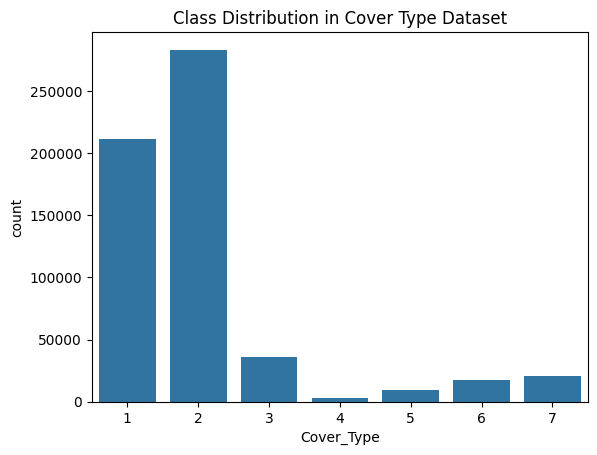

In [5]:
sns.countplot(x=target_col, data=df)
plt.title("Class Distribution in Cover Type Dataset")
plt.show()

## Make a Model

We can now define our model. As with datasets, it is a bit more involved than with sklearn, as we have the ability to create all kinds of custom architectures targeted at specific problems. For this example, we'll make a simple feedforward neural network for classification. The model will consist of several linear layers with ReLU activations in between, and a final output layer with a softmax activation to produce class probabilities.

### Model Parts

There are a few parts to the model. Again, we have quite a bit of flexibility in how we implement things, as long as we meet the requirements of the PyTorch framework. The main requirement is that we define a class that inherits from `torch.nn.Module`, and implement the `__init__` and `forward` methods. Most of the logic that we saw in the by-hand example is built into the torch framework, so we can ignore most of that and provide the core bits:
<ul>
<li>`__init__`: This method initializes the model, defining the layers and any other components needed.</li>
    <ul>
    <li> The `super().__init__()` call is necessary to properly initialize the base class.</li>
    <li> Each other attribute is one of the layers of the model, defined using PyTorch's built-in layer classes.</li>
    </ul>
<li>`forward`: This method defines the forward pass of the model, specifying how the input data flows through the layers to produce the output.</li>
    <ul>
    <li> The input `x` is passed through each layer in sequence, with activation functions applied as needed.</li>
    <li> The final output is returned, which will be used for loss calculation and predictions.</li>
    <li> Note that we don't need to define the backward pass, PyTorch automatically computes gradients using autograd.</li>
    <li> Also note, we are using the layer attributes one-by-one, they aren't automatically connected in order - we have to define the flow of data explicitly in the `forward` method.</li>
    </ul>
</ul>

Below in the `SequentialModel` class there's an example of an equivalent model using the `torch.nn.Sequential` container, which allows us to define the model as a sequence of layers without explicitly defining the `forward` method. This can be more concise for simple models, but is less flexible for complex architectures. These two models are functionally equivalent - the only time we care is if we need to do something that the `Sequential` container can't handle easily.

In [6]:
#create model

class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, debug_preds=False):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.debug_preds = debug_preds
        if debug_preds:
            print("Debugging of predictions is enabled.")
        
    def forward(self, x):
       x = self.fc1(x)
       x = self.relu(x)
       x = self.fc2(x)
       x = self.relu2(x)
       x = self.fc3(x)
       if self.debug_preds:
           print(f"Debug: Output predictions: {x}")
       return x

# This is equivalent to the SimpleNN above, but uses nn.Sequential to define the model in a more compact way.
class SequentialModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SequentialModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )
    
    def forward(self, x):
        return self.model(x)

#### Define Some Constants

There are typically several things we need to configure before we can create and train the model. These include things such as the input size (number of features), epochs to train for, learning rate, etc. We'll group a bunch of the definitions here, so it is easy to find and adjust them as needed.

<b>Note:</b> There are some constants defined earlier, that's because we are looking at them bit-by-bit. In a real example, these would all be together at the top of the notebook/script.

In [7]:
LEARNING_RATE = 0.015
INPUT_SIZE = len(feature_cols)
HIDDEN_SIZE = 32
OUTPUT_SIZE = len(df[target_col].value_counts())

print(f"Model Settings: Input Size={INPUT_SIZE}, Hidden Size={HIDDEN_SIZE}, Output Size={OUTPUT_SIZE}")
print(f"Training for {EPOCHS} epochs with learning rate {LEARNING_RATE}")

Model Settings: Input Size=54, Hidden Size=32, Output Size=7
Training for 100 epochs with learning rate 0.015


## Training the Model

To train the model, we first need to define a loss function and an optimizer. The loss function measures how well the model's predictions match the true labels, and the optimizer updates the model's weights based on the computed gradients to minimize the loss. The optimizer takes the model's parameters and a learning rate as input, it'll then use these to do all of the adjustments during training process, without us needing to manage the details and math ourselves.

#### Construct the Model

The model constructor makes a model object, basically the structure of all the weights and biases, but they are not useful yet. We can have parameters like the ones we included here to let us customize things. Most frequently, we can use these parameters to allow us to create different shaped/sized models without having to remake everything - if we are tuning the model, this can make it easier to try different model designs, which can radically impact performance. We can also add whatever else we want, here I added a flag to enable some debugging print statements - this came from real-life experience, I originally had made a mistake in the number of classes and had to track it down. 

#### Optimizer

The optimizer isn't a huge concern for us, but it is important. This is the algorithm that actually updates the weights based on the gradients we compute during backpropagation. There are many different ones, the Adam optimizer is a good general-purpose choice that works well in many scenarios, so it's a common default. The learning rate is a key hyperparameter that controls how big of a step we take during each update - too high and we might overshoot the optimal weights, too low and training can be very slow. The learning rate can often be tuned to improve performance. For our usage, we won't worry too much about optimizers, but in more complex scenarios, selecting and tuning the optimizer can be important. Large models like ChatGPT or a self-driving car can cost hundreds of millions of dollars to train, and take weeks of time while running on clusters of 10s of thousands of GPUs - in those cases, even small improvements in training efficiency can lead to huge cost savings, so there's a lot of research into optimizers and training techniques for those scenarios. The nerdiest people from my computer science classes, along with math grad students, tend to end up working on those problems. 

The optimizer takes an input of the model's parameters. It basically captures those parameters and manages all the reading and updating for us. 

#### Loss Function

The loss function is how the model measures the error while training, the same as with the classical models, but with a little more variety. One thing that we need to be careful of is ensuring that the:
<ul>
<li> Model's output. </li>
<li> Loss function's expected input. </li>
<li> The format of the target labels. </li>
</ul>
all match up. In this case, we are using `CrossEntropyLoss`, which expects raw scores (logits) from the model, and target labels as class indices (not one-hot encoded). In the model's structure, we can see that the final output is the logit - we don't apply activation there at all. In the dataset, we ensured that the target labels were integers starting from 0, which matches what `CrossEntropyLoss` expects. If these don't align, we'll get errors during training or poor performance.

We always need to check this, for regression it is usually simple - no activation and MSELoss. For classification, we need to be more careful about the details. Some good default choices are:
<ul>
<li> For multi-class classification (more than 2 classes): use `CrossEntropyLoss` with raw logits from the model and integer class labels (no final activation).</li>
<li> For binary classification (2 classes): use `BCEWithLogitsLoss` with raw logits from the model and binary labels (0 or 1).</li>
</ul>
These are only starting points, some scenarios perform better with different choices, like hinge loss. In general, especially for a simple multi-class problem, there are several ways to get to the final result, mainly differing in where the activation function is applied (in the model or in the loss function). Conceptually, any working configuration is doing the same thing and is interchangable, but the recommended defaults tend to perform somewhat better, for small optimization reasons. 

In the example here (down a bit lower), there's a flag to enable class weights for imbalanced classes. This is a common technique to help the model pay more attention to under-represented classes during training. The weights are calculated based on the frequency of each class in the dataset, and passed to the loss function. This way, when the model makes a mistake on a sample from a minority class, the loss will be higher, encouraging the model to learn better representations for those classes.

In [8]:
# Define the loss function and optimizer
model = SimpleNN(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, output_size=OUTPUT_SIZE, debug_preds=False)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

## Training Loops

We need to manually define the loop that trains our model. Some core parts that we need to be sure to include are:
<ul>
<li> Send the model and the data to the device. We selected the device avaiable earlier, but we need to actually move the model and data to that device for processing.</li>
<li> Set the model to training mode. This is done by calling `model.train()`. Some layers behave differently during training and evaluation, so we need to set the mode appropriately.</li>
<li><b>Train for several epochs, for each:</b></li>
    <ul>
    <li> Loop over the data in batches. The dataloader provides an iterable over the dataset, yielding batches of data. For each batch:</li>
        <ul>
        <li> Zero the gradients. Before each batch, we need to zero the gradients of the model's parameters. This is done using `optimizer.zero_grad()`.</li>
        <li> Forward pass. We pass the input data through the model to get predictions.</li>
        <li> Compute the loss. We calculate the loss between the model's predictions and the true labels.</li>
        <li> Backward pass. We compute the gradients of the loss with respect to the model's parameters using `loss.backward()`.</li>
        <li> Update the weights. We update the model's parameters using the optimizer's `step()` method.</li>
        </ul>
    <li> Calculate validation metrics. After each epoch, we can evaluate the model on the validation dataset to monitor its performance and adjust hyperparameters if needed.</li>
    </ul>
</ul>

Some parts that we should pay attention to include the difference between training and evaluation modes. When in the training mode versus evaluation mode, a few things change:
<ul>
<li> Layers like dropout and batch normalization behave differently during training and evaluation. In training mode, dropout randomly zeroes some activations to prevent overfitting, while in evaluation mode, it uses all activations. Batch normalization uses batch statistics during training and running averages during evaluation.</li>
<li> We need to ensure that we set the model to evaluation mode using `model.eval()` when evaluating the model on validation or test data. This ensures that the layers behave correctly for inference.</li>
<li> During evaluation, we typically don't need to compute gradients, so we can wrap the evaluation code in a `with torch.no_grad():` block to save memory and computation.</li>
</ul>

This stuff is easy to forget (and honestly something that I kind of think PyTorch could make more automatic), so it's good to keep in mind.

In [9]:
def train_model(model, train_dataloader, val_dataloader, criterion, optimizer, epochs):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_dataloader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_dataloader.dataset)
        print(f"Epoch {epoch+1}/{epochs}: \n\tTraining Loss: {epoch_loss:.4f}")
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for inputs, labels in val_dataloader:
                inputs, labels = inputs.to(device), labels.to(device).long()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
        
        val_epoch_loss = val_loss / len(val_dataloader.dataset)
        val_accuracy = correct / len(val_dataloader.dataset)
        print(f"\tValidation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def test_model(test_dataloader, model, print_pred_and_label=False):
    model.to(device)
    model.eval()
    correct = 0
    preds_labels = []
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            preds_labels.extend(zip(preds.cpu().numpy(), labels.cpu().numpy()))
    test_accuracy = correct / len(test_dataloader.dataset)
    #print(f"Test Accuracy: {test_accuracy:.4f}")
    if print_pred_and_label:
        for pred, label in preds_labels:
            #print(f"Predicted: {pred}, Actual: {label}")
            pass
    return preds_labels


In [10]:
train_model(model, train_dataloader, val_dataloader, criterion, optimizer, EPOCHS)
test_preds = test_model(test_dataloader, model, print_pred_and_label=False)

Epoch 1/100: 
	Training Loss: 0.6052
	Validation Loss: 0.5261, Validation Accuracy: 0.7717
Epoch 2/100: 
	Training Loss: 0.5044
	Validation Loss: 0.5303, Validation Accuracy: 0.7741
Epoch 3/100: 
	Training Loss: 0.4744
	Validation Loss: 0.4701, Validation Accuracy: 0.7982
Epoch 4/100: 
	Training Loss: 0.4552
	Validation Loss: 0.4583, Validation Accuracy: 0.8048
Epoch 5/100: 
	Training Loss: 0.4450
	Validation Loss: 0.4632, Validation Accuracy: 0.7953
Epoch 6/100: 
	Training Loss: 0.4337
	Validation Loss: 0.4384, Validation Accuracy: 0.8152
Epoch 7/100: 
	Training Loss: 0.4296
	Validation Loss: 0.4355, Validation Accuracy: 0.8160
Epoch 8/100: 
	Training Loss: 0.4232
	Validation Loss: 0.4478, Validation Accuracy: 0.8043
Epoch 9/100: 
	Training Loss: 0.4170
	Validation Loss: 0.4476, Validation Accuracy: 0.8134
Epoch 10/100: 
	Training Loss: 0.4148
	Validation Loss: 0.4208, Validation Accuracy: 0.8207
Epoch 11/100: 
	Training Loss: 0.4128
	Validation Loss: 0.4244, Validation Accuracy: 0.82

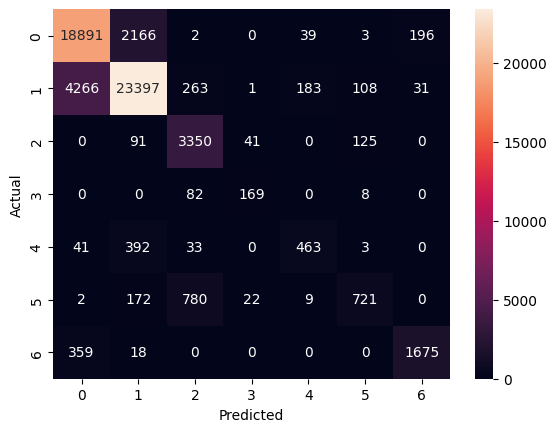

In [11]:
test_preds = test_model(test_dataloader, model)
sns.heatmap(pd.crosstab(
    pd.Series([label for _, label in test_preds], name='Actual'),
    pd.Series([pred for pred, _ in test_preds], name='Predicted')
), annot=True, fmt='d')
plt.show()

Full Dataset Accuracy: 0.8381


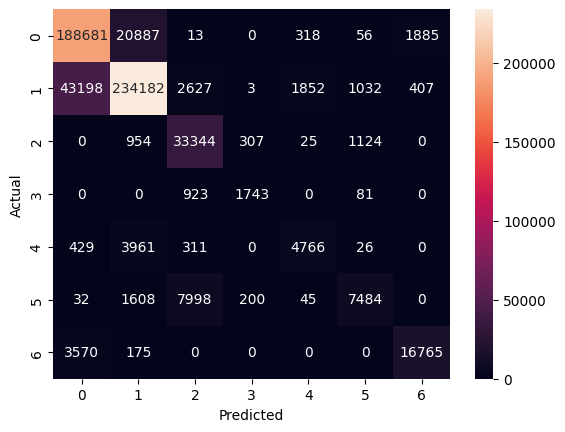

In [12]:
# Run full test of all data
full_dataset = CustomDataset(dataframe=df, feature_colnames=feature_cols, target_colname=target_col)
full_dataloader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)
full_preds = test_model(full_dataloader, model)
print(f"Full Dataset Accuracy: {len([1 for pred, label in full_preds if pred == label]) / len(full_preds):.4f}")
sns.heatmap(pd.crosstab(
    pd.Series([label for _, label in full_preds], name='Actual'),
    pd.Series([pred for pred, _ in full_preds], name='Predicted')
), annot=True, fmt='d')
plt.show()

## Imbalanced Data

### Weighted Trial

We can use class weights to help with imbalanced datasets. This is a neural-network-y way to deal with class imbalance, when the loss is computed, it scales the impact based on the weight of that class. This can serve to equalize the importance of each class during training, helping the model to learn better representations for minority classes.

In [13]:
criterion_weight = nn.CrossEntropyLoss(weight=class_weights_tensor)

train_model(model, train_dataloader, val_dataloader, criterion_weight, optimizer, EPOCHS)
weight_preds = test_model(full_dataloader, model, print_pred_and_label=False)

Epoch 1/100: 
	Training Loss: 0.5607
	Validation Loss: 0.4872, Validation Accuracy: 0.7517
Epoch 2/100: 
	Training Loss: 0.4708
	Validation Loss: 0.4993, Validation Accuracy: 0.7744
Epoch 3/100: 
	Training Loss: 0.4570
	Validation Loss: 0.4573, Validation Accuracy: 0.7433
Epoch 4/100: 
	Training Loss: 0.4416
	Validation Loss: 0.4626, Validation Accuracy: 0.7498
Epoch 5/100: 
	Training Loss: 0.4328
	Validation Loss: 0.4477, Validation Accuracy: 0.7540
Epoch 6/100: 
	Training Loss: 0.4294
	Validation Loss: 0.4971, Validation Accuracy: 0.7478
Epoch 7/100: 
	Training Loss: 0.4262
	Validation Loss: 0.4455, Validation Accuracy: 0.7528
Epoch 8/100: 
	Training Loss: 0.4169
	Validation Loss: 0.4266, Validation Accuracy: 0.7724
Epoch 9/100: 
	Training Loss: 0.4139
	Validation Loss: 0.4301, Validation Accuracy: 0.7609
Epoch 10/100: 
	Training Loss: 0.4089
	Validation Loss: 0.4425, Validation Accuracy: 0.7298
Epoch 11/100: 
	Training Loss: 0.4082
	Validation Loss: 0.4254, Validation Accuracy: 0.76

### Stratified Data Trial

We can notice that the dataset is imbalanced, with some classes having significantly more samples than others. Our predictions don't really appear to be reflecting reality for infrequent classes. 

Epoch 1/100: 
	Training Loss: 0.3838
	Validation Loss: 0.3902, Validation Accuracy: 0.7684
Epoch 2/100: 
	Training Loss: 0.3743
	Validation Loss: 0.3638, Validation Accuracy: 0.7784
Epoch 3/100: 
	Training Loss: 0.3711
	Validation Loss: 0.3848, Validation Accuracy: 0.7471
Epoch 4/100: 
	Training Loss: 0.3719
	Validation Loss: 0.3652, Validation Accuracy: 0.7791
Epoch 5/100: 
	Training Loss: 0.3676
	Validation Loss: 0.3728, Validation Accuracy: 0.7807
Epoch 6/100: 
	Training Loss: 0.3689
	Validation Loss: 0.3748, Validation Accuracy: 0.7660
Epoch 7/100: 
	Training Loss: 0.3693
	Validation Loss: 0.3672, Validation Accuracy: 0.7633
Epoch 8/100: 
	Training Loss: 0.3678
	Validation Loss: 0.3613, Validation Accuracy: 0.7713
Epoch 9/100: 
	Training Loss: 0.3695
	Validation Loss: 0.4355, Validation Accuracy: 0.7699
Epoch 10/100: 
	Training Loss: 0.3836
	Validation Loss: 0.3820, Validation Accuracy: 0.7444
Epoch 11/100: 
	Training Loss: 0.3685
	Validation Loss: 0.3669, Validation Accuracy: 0.78

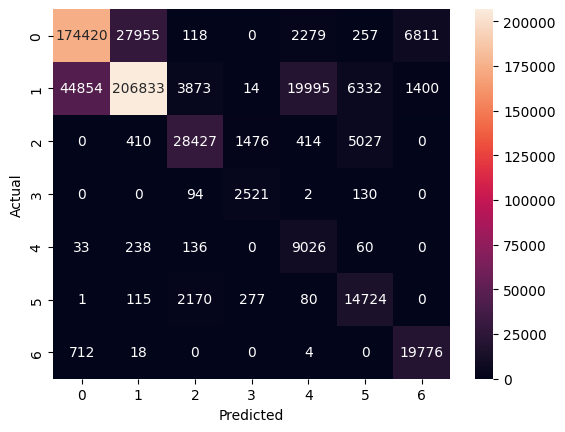

In [14]:
from sklearn.model_selection import StratifiedKFold

stratTrain, stratVal = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target_col])

strat_train_dataset = CustomDataset(dataframe=stratTrain, feature_colnames=feature_cols, target_colname=target_col)
strat_train_dataloader = DataLoader(strat_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
strat_val_dataset = CustomDataset(dataframe=stratVal, feature_colnames=feature_cols, target_colname=target_col)
strat_val_dataloader = DataLoader(strat_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

train_model(model, strat_train_dataloader, strat_val_dataloader, criterion_weight, optimizer, EPOCHS)
strat_preds = test_model(full_dataloader, model)
sns.heatmap(pd.crosstab(
    pd.Series([label for _, label in strat_preds], name='Actual'),
    pd.Series([pred for pred, _ in strat_preds], name='Predicted')
), annot=True, fmt='d')
plt.show()